<a href="https://colab.research.google.com/github/jfaraudo/Schrodinger_Numerical/blob/main/HarmonicOscillator/Quantum_Harmonic_Oscillator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Particle in a Lennard-Jones Potential**
Eric Rausa, niu 1620494



The code assumed the particle is an electron and we use Atomic Units.   
We start importing libraries:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

We use the same parameters (same constants) as in this Chemistry LibreText example https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Quantum_Tutorials_(Rioux)/09%3A_Numerical_Solutions_for_Schrodinger's_Equation/9.13%3A_Numerical_Solutions_for_the_Lennard-Jones_Potential

## Definició de constants i matriu

In [2]:
#definim diferents valors de les constants
e=100.0
sigma=1.0

In [38]:
#Potential as a function of position
def getV(x):
    e=100.0
    sigma=1.0
    potvalue = 4*e*((sigma/x)**12-(sigma/x)**6)
    return potvalue

Definim la funció per calcular la matriu que ens permetra resoldre la equació de Shrodinger. Fem que vagi de 0 fins a n-1

In [39]:
#Discretized Schrodinger equation in n points (FROM 0 to n-1)
def Eq(n,h,x):
    F = np.zeros([n,n])
    for i in range(0,n):
        F[i,i] = -2*((h**2)*getV(x[i]) + 1)
        if i > 0:
           F[i,i-1] = 1
           if i < n-1:
              F[i,i+1] = 1
    return F

Acabem de definir el potencial de la funció i la matriu per calcular les solucions, però encara no hem fet res per resoldre-ho

## Busqueda de solucions

Per trobar les solucions numèriques, posem els diferents parametres que necessitem: La discretització (h) i el tamany de la caixa (L).

In [40]:
# Interval per calcular la funció, de -L/2 a L/2
L = 100
xlower = 3*L/400.0
xupper = 7*L/200.0

h = 0.005  #discretizació en l'espai

#Creem les cordenades per trobar la solució
x = np.arange(xlower,xupper+h,h)
#Ara veiem quants punts tenim dins de la "quadricula"
npoints=len(x)

print("Tenim",npoints, "grid points.")

Tenim 551 grid points.


Calculem de forma explicita la funció F i diagonalitzem, tenint en compte que els resultats obtinguts no estaràn ordenats

In [51]:
#Calculation of discrete form of Schrodinger Equation and diagonalization
F=Eq(npoints,h,x)
eigenValues, eigenVectors = np.linalg.eig(F)

print(F)

[[-2.51901272  0.          0.         ...  0.          0.
   0.        ]
 [ 1.         -2.47501611  1.         ...  0.          0.
   0.        ]
 [ 0.          1.         -2.43481236 ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ... -1.99998894  1.
   0.        ]
 [ 0.          0.          0.         ...  1.         -1.99998903
   1.        ]
 [ 0.          0.          0.         ...  0.          1.
  -1.99998913]]


In [52]:
#Ordenem els resultats depenent al eigenvalue, on w són els eigenvalues ordenats, i vectors els eigenvectors
# w ordered eigenvalues and vs ordered eigenvectors
idx=eigenValues.argsort()[::-1]
w=eigenValues[idx]
vectors=eigenVectors[:,idx]

Ara que ja tenim els eigenvalors ordenats, busquem les energies més baixes, ja que sabem relacionar fàcilment eigenvalues i energies amb la seguent fórmula:

In [53]:
#Energy Levels, per fer servir el rang, fem servir el que posa en l'exemple, on la x minima val 0.75, i la maxima val 3.5
E = - w/(2.0*h**2)
for k in range(0,5):
  print("n=",k,", E(numeric)=%.4f" %E[k])

n= 0 , E(numeric)=-66.2726
n= 1 , E(numeric)=-22.9867
n= 2 , E(numeric)=-4.1353
n= 3 , E(numeric)=1.1076
n= 4 , E(numeric)=5.9802


Ara busquem les funcions d'ona, per poder-es veure en un gràfic

Plotting


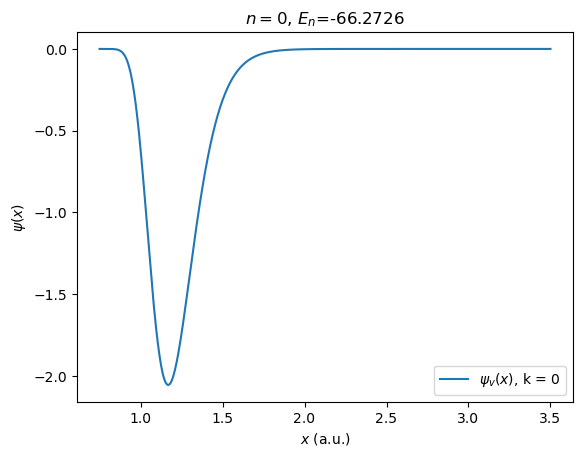

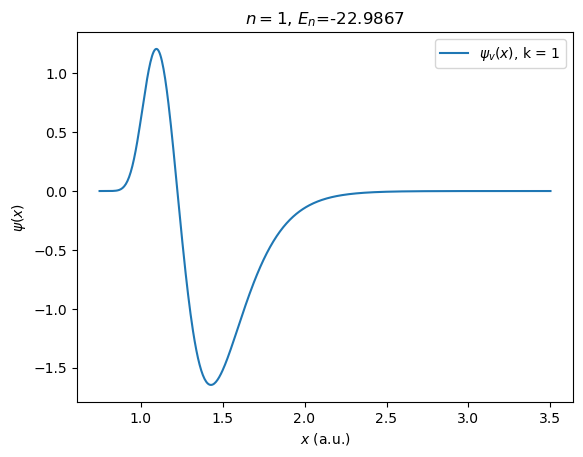

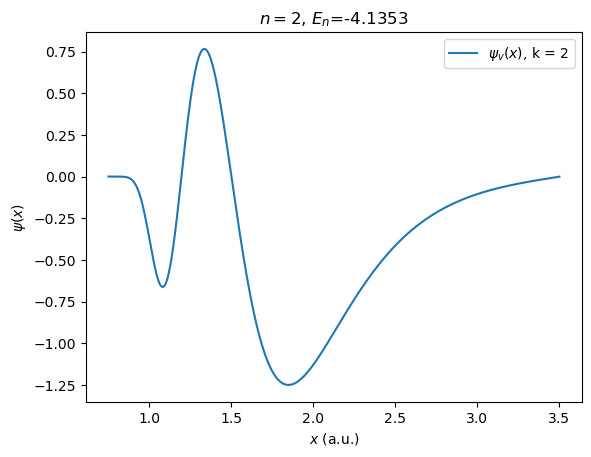

In [54]:
#Init Wavefunction (empty list with npoints elements)
psi = [None]*npoints

#Calculation of normalised Wave Functions
for k in range(0,len(w)):
	psi[k] = vectors[:,k]
	integral = h*np.dot(psi[k],psi[k])
	psi[k] = psi[k]/integral**0.5

#Plot Wave functions
print("Plotting")

#v = int(input("\n Quantum Number (enter 0 for ground state):\n>"))
for v in range(0,3):
	plt.plot(x,psi[v],label=r'$\psi_v(x)$, k = ' + str(v))
	plt.title(r'$n=$'+ str(v) + r', $E_n$=' + '{:.4f}'.format(E[v]))
	plt.legend()
	plt.xlabel(r'$x$ (a.u.)')
	plt.ylabel(r'$\psi(x)$')
	plt.show()


## Calcul de la probabilitat

Plotting probabilities


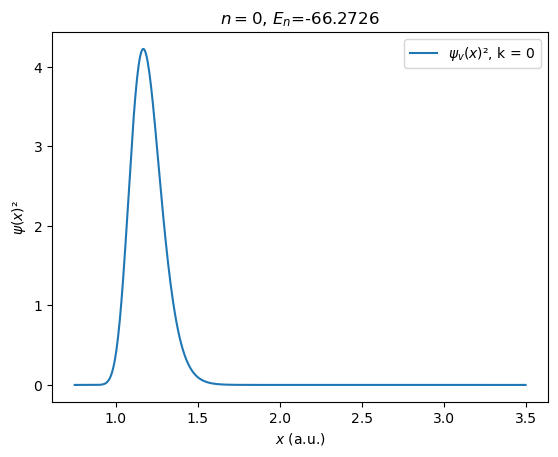

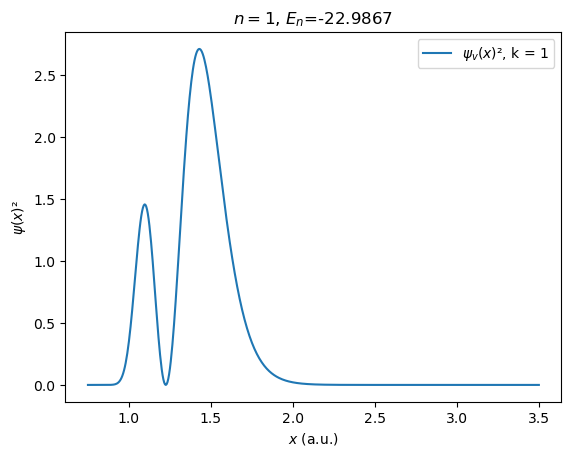

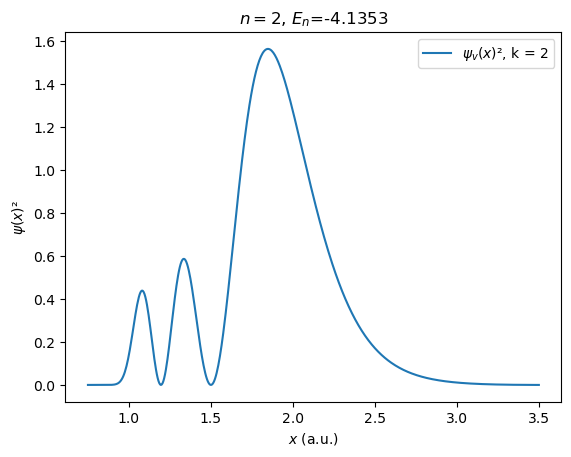

chao :)


In [55]:
#Ara, per últim, i com a extra, plottejem les probabilitats per a cada funció d'ona:
prob=(psi[k])**2

print("Plotting probabilities")

#v = int(input("\n Quantum Number (enter 0 for ground state):\n>"))
for v in range(0,3):
	plt.plot(x,(psi[v])**2,label=r'$\psi_v(x)²$, k = ' + str(v))
	plt.title(r'$n=$'+ str(v) + r', $E_n$=' + '{:.4f}'.format(E[v]))
	plt.legend()
	plt.xlabel(r'$x$ (a.u.)')
	plt.ylabel(r'$\psi(x)²$')
	plt.show()


print("chao :)")


## ara mirem el que succeix si fem un valor major de discretització

In [65]:
#ara mirem el que succeix si fem una discretització major. Per exemple, fent que h=0.05
#al disminuir el nombre de punts, veurem resultats menys precisos, però a canvi aconseguim tindre menys temps de calcul.

# Interval per calcular la funció, de -L/2 a L/2
L = 100
xlower = 3*L/400.0
xupper = 7*L/200.0

h = 0.05  #discretizació en l'espai

#Creem les cordenades per trobar la solució
x = np.arange(xlower,xupper+h,h)
#Ara veiem quants punts tenim dins de la "quadricula"
npoints=len(x)

print("Tenim",npoints, "grid points.")

Tenim 56 grid points.


In [66]:
#Calculation of discrete form of Schrodinger Equation and diagonalization
F=Eq(npoints,h,x)
eigenValues, eigenVectors = np.linalg.eig(F)

print(F)

[[-53.9012722    0.           0.         ...   0.           0.
    0.        ]
 [  1.         -23.47443593   1.         ...   0.           0.
    0.        ]
 [  0.           1.         -10.75763203 ...   0.           0.
    0.        ]
 ...
 [  0.           0.           0.         ...  -1.99870618   1.
    0.        ]
 [  0.           0.           0.         ...   1.          -1.99881462
    1.        ]
 [  0.           0.           0.         ...   0.           1.
   -1.99891261]]


In [67]:
#Ordenem els resultats depenent al eigenvalue, on w són els eigenvalues ordenats, i vectors els eigenvectors
# w ordered eigenvalues and vs ordered eigenvectors
idx=eigenValues.argsort()[::-1]
w=eigenValues[idx]
vectors=eigenVectors[:,idx]

In [68]:
#Energy Levels, per fer servir el rang, fem servir el que posa en l'exemple, on la x minima val 0.75, i la maxima val 3.5
E = - w/(2.0*h**2)
for k in range(0,5):
  print("n=",k,", E(numeric)=%.4f" %E[k])

n= 0 , E(numeric)=-66.6045
n= 1 , E(numeric)=-23.5552
n= 2 , E(numeric)=-4.4455
n= 3 , E(numeric)=0.9037
n= 4 , E(numeric)=5.4415


## Gràfics de funcions d'ona amb major discretització

Plotting


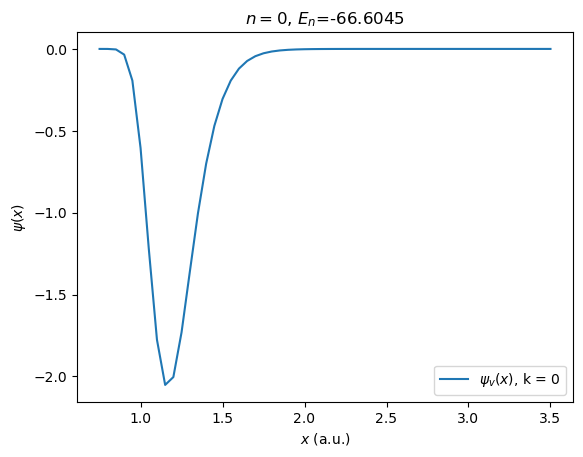

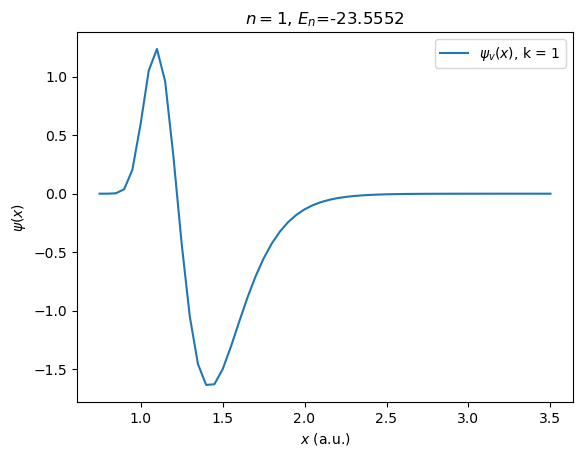

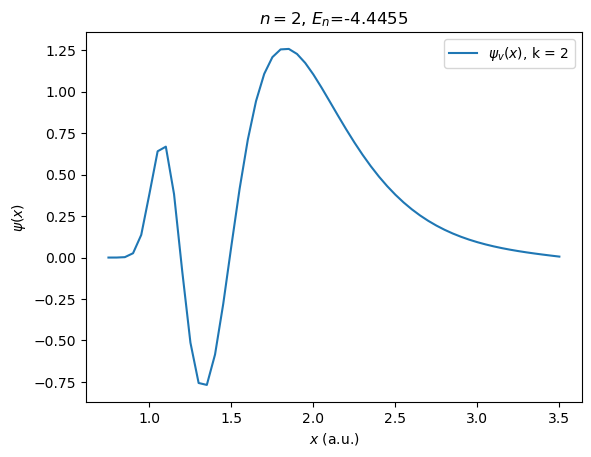

In [63]:
#Veiem que els valors de les energies són lleugerament diferents, els resultats varien lleugerament apartir del primer decimal
#ara veurem com varia en el gràfic de de la funció d'ona:
#Init Wavefunction (empty list with npoints elements)
psi = [None]*npoints

#Calculation of normalised Wave Functions
for k in range(0,len(w)):
	psi[k] = vectors[:,k]
	integral = h*np.dot(psi[k],psi[k])
	psi[k] = psi[k]/integral**0.5

#Plot Wave functions
print("Plotting")

#v = int(input("\n Quantum Number (enter 0 for ground state):\n>"))
for v in range(0,3):
	plt.plot(x,psi[v],label=r'$\psi_v(x)$, k = ' + str(v))
	plt.title(r'$n=$'+ str(v) + r', $E_n$=' + '{:.4f}'.format(E[v]))
	plt.legend()
	plt.xlabel(r'$x$ (a.u.)')
	plt.ylabel(r'$\psi(x)$')
	plt.show()



veiem que es tracta de gràfics amb menys precisió. Si disminuissim molt la discretització, per exemple h=0,0001
Obtindrem resultats més precisos, però tardarà molt més temps en calcular-ho l'ordinador. 
Disminuir la discretització és útil quan varía molt la funció d'ona en un espai de x molt petit. 
Sabem que tenim una bona discertització quan al disminuirla discretització, no varía l'energia en un ordre de magnitut rellevant.